# Allen–Cahn ROM results

Load one ROM run or a directory of ROM runs. `trajectory_data` contains one reusable reference/learned solve per run.


In [1]:
repo_root = normpath(joinpath(@__DIR__, "..", "..", ".."))
import Pkg
Pkg.activate(joinpath(repo_root, "Julia"))
include(joinpath(repo_root, "src", "Tools", "Visualizations", "visualizations.jl"))


  Activating 

[package-load] Loading LinearAlgebra


project at `~/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven_main/Julia`


[package-load] Loaded LinearAlgebra
[package-load] Loading SparseArrays
[package-load] Loaded SparseArrays
[package-load] Loading Statistics
[package-load] Loaded Statistics
[package-load] Loading Random
[package-load] Loaded Random
[package-load] Loading ComponentArrays
[package-load] Loaded ComponentArrays
[package-load] Loading LinearSolve
[package-load] Loaded LinearSolve
[package-load] Loading OrdinaryDiffEq
[package-load] Loaded OrdinaryDiffEq
[package-load] Loading OrdinaryDiffEqSDIRK
[package-load] Loaded OrdinaryDiffEqSDIRK
[package-load] Loading OrdinaryDiffEqLowOrderRK
[package-load] Loaded OrdinaryDiffEqLowOrderRK
[package-load] Loading SciMLSensitivity
[package-load] Loaded SciMLSensitivity
[package-load] Loading ADTypes
[package-load] Loaded ADTypes
[package-load] Loading Zygote
[package-load] Loaded Zygote
[package-load] Loading Mooncake
[package-load] Loaded Mooncake
[package-load] Loading Optimization
[package-load] Loaded Optimization
[package-load] Loading Optimizati

save_rom_stability_gif

In [2]:
input_path = joinpath(repo_root, "Data/A-C/Random_noise/ROM/01_02_N64_first_pass_and_longer/AC_ROM_fixed_2D_random_noise_cartesian_21_etas-0.005_0.0015_0.0005__window_t-0.05_0.5_2.0__window_n_obs-2_10_20__m-10__r-20")
dir_of_dirs = false
run_dirs = visualization_run_directories(input_path; dir_of_dirs, mode=:rom)
trajectory_data = Dict(run_dir => solve_run_trajectories(run_dir) for run_dir in run_dirs)
nothing


In [3]:
selected_run = first(run_dirs)


"/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven_main/Data/A-C/Random_noise/ROM/01_02_N64_first_pass_and_longer/AC_ROM_fixed_2D_random_noise_cartesian_21_etas-0.005_0.0015_0.0005__window_t-0.05_0.5_2.0__window_n_obs-2_10_20__m-10__r-20"

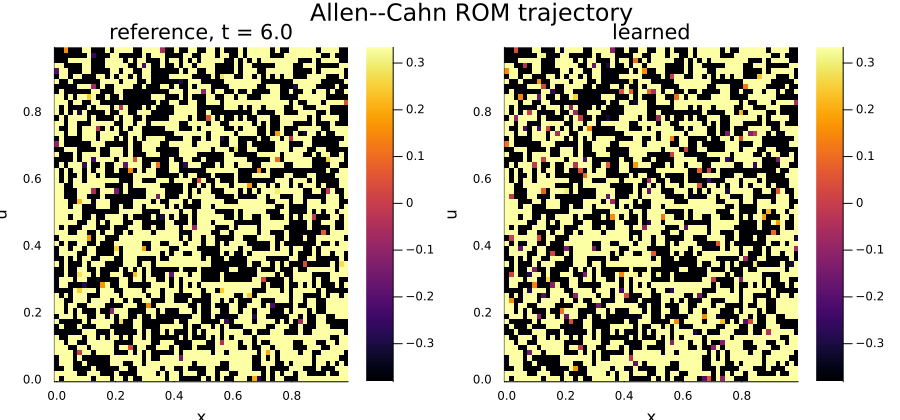

┌ Info: Saved animation to /Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven_main/Data/A-C/Random_noise/ROM/01_02_N64_first_pass_and_longer/AC_ROM_fixed_2D_random_noise_cartesian_21_etas-0.005_0.0015_0.0005__window_t-0.05_0.5_2.0__window_n_obs-2_10_20__m-10__r-20/visualizations/ac_rom_comparison.gif
└ @ Plots /Users/milesgantcher/.julia/packages/Plots/GIume/src/animation.jl:156


"/Users/milesgantcher/Library/CloudStorage/OneDrive-RiceUniversity/Documents/VSCode_Projects/Brookhaven_main/Data/A-C/Random_noise/ROM/01_02_N64_first_pass_and_longer/AC_ROM_fixed_2D_random_noise_cartesian_21_etas-0.005_0.0015_0.0005__window_t-0.05_0.5_2.0__window_n_obs-2_10_20__m-10__r-20/visualizations/ac_rom_comparison.gif"

In [4]:
comparison = plot_trajectory_comparison(trajectory_data[selected_run]; title="Allen--Cahn ROM trajectory", xlabel="x", ylabel="u", colorbar=true, save_name="ac_rom_comparison.png")
gif_path = save_trajectory_gif(trajectory_data[selected_run]; title="Allen--Cahn ROM trajectory", max_frames=60, fps=8, colorbar=true, name="ac_rom_comparison.gif")
display(comparison)
gif_path


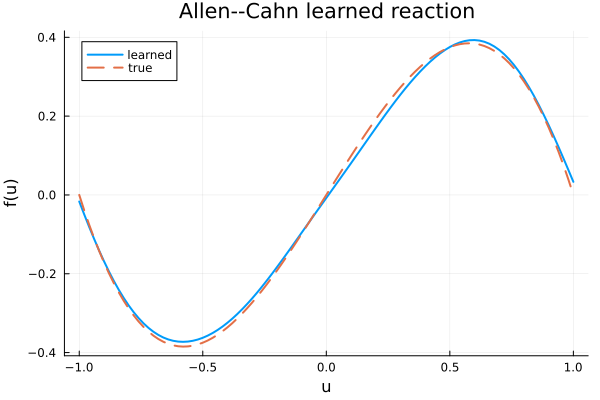

AC_ROM_fixed_2D_random_noise_cartesian_21_etas-0.005_0.0015_0.0005__window_t-0.05_0.5_2.0__window_n_obs-2_10_20__m-10__r-20: final learned-function L2 error = 0.01737350023079067


0.01737350023079067

In [5]:
function_plot = plot_learned_function(selected_run; plot_true=true, title="Allen--Cahn learned reaction", xlabel="u", ylabel="f(u)", save_name="ac_rom_learned_function.png")
display(function_plot)
print_final_function_l2_error(selected_run)


In [9]:
for (key, value) in pairs(data)
    if value isa AbstractArray
        println("$key : $(summary(value))")
    else
        println("$key : $value")
    end
end

N : 4096
grid_N : 64
dimension : 2
boundary_condition : periodic
state_shape : (64, 64)
ε2 : 1.0e-5
k : 1.0
Δx : 0.015625
Δmeasure : 0.000244140625
tspan : (0.0, 6.0)
t_obs : 99-element Vector{Float64}
u₀ : 4096-element Vector{Float64}
reference_saved_times : 20-element Vector{Float64}
r : 20
m : 10
spatial_modes : 4096×20 Matrix{Float64}
deim_modes : 4096×10 Matrix{Float64}
deim_indices : 10-element Vector{Int64}
state_singular_values : 20-element Vector{Float64}
nonlinear_singular_values : 20-element Vector{Float64}
learner : NN
model_type : NN
polynomial_degree : nothing
polynomial_coefficient_order : nothing
polynomial_initial_coefficients : nothing
polynomial_final_coefficients : nothing
h : 8
activation : tanh
seed : 1
use_default_nonlinearity : true



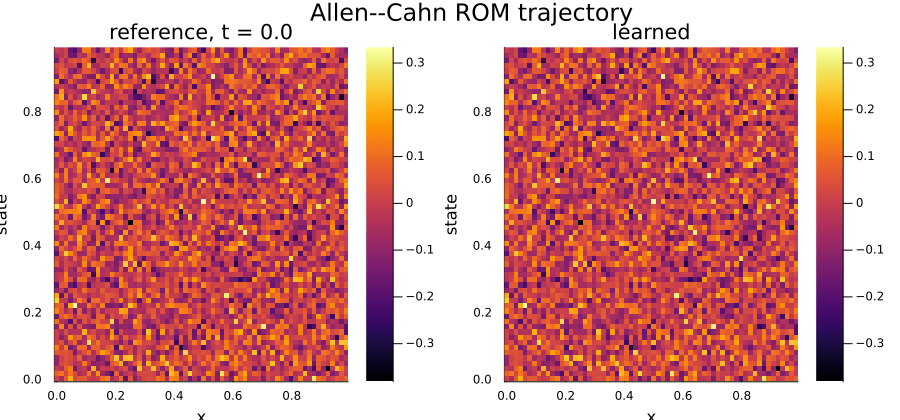

In [10]:
using Base64

gif_html = """
<img src="data:image/gif;base64,$(base64encode(read(gif_path)))">
"""

display("text/html", gif_html)